
Running Petrosian FD in FAST mode
decimate=2, max_samples=60000
Loaded EEG segment: 106944 samples x 32 channels
Segment: [814.571, 921.515] sec
After FAST mode preprocessing:
  Segment shape: 53472 samples x 32 channels
  Effective sampling rate: 500.00 Hz
  Effective duration: 106.94 sec

Petrosian Fractal Dimensions:
   channel  petrosian_fd  n_samples  n_delta  delta_density  \
0      FC1      1.022167      53472    35598       0.665756   
1       C3      1.022142      53472    35554       0.664934   
2       Cz      1.021786      53472    34928       0.653226   
3      CP1      1.021760      53472    34882       0.652366   
4       F3      1.021746      53472    34858       0.651917   
5      FC2      1.021732      53472    34832       0.651431   
6      FC5      1.021729      53472    34828       0.651356   
7       Fz      1.021703      53472    34782       0.650496   
8      CP2      1.021669      53472    34722       0.649373   
9       Pz      1.021581      53472    34568   

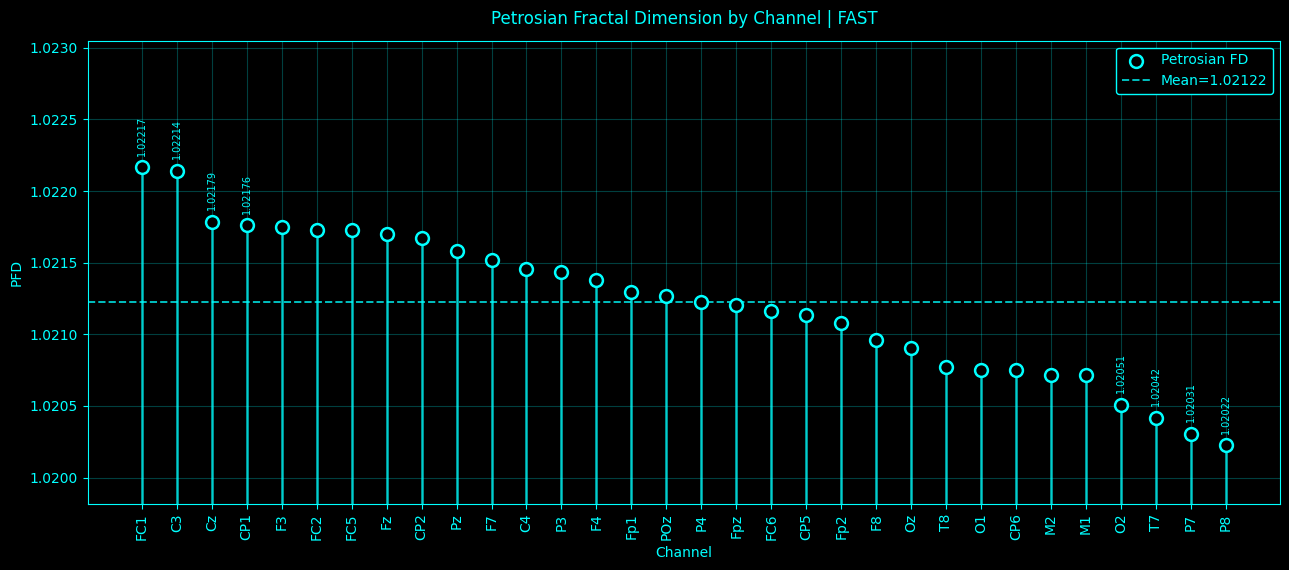

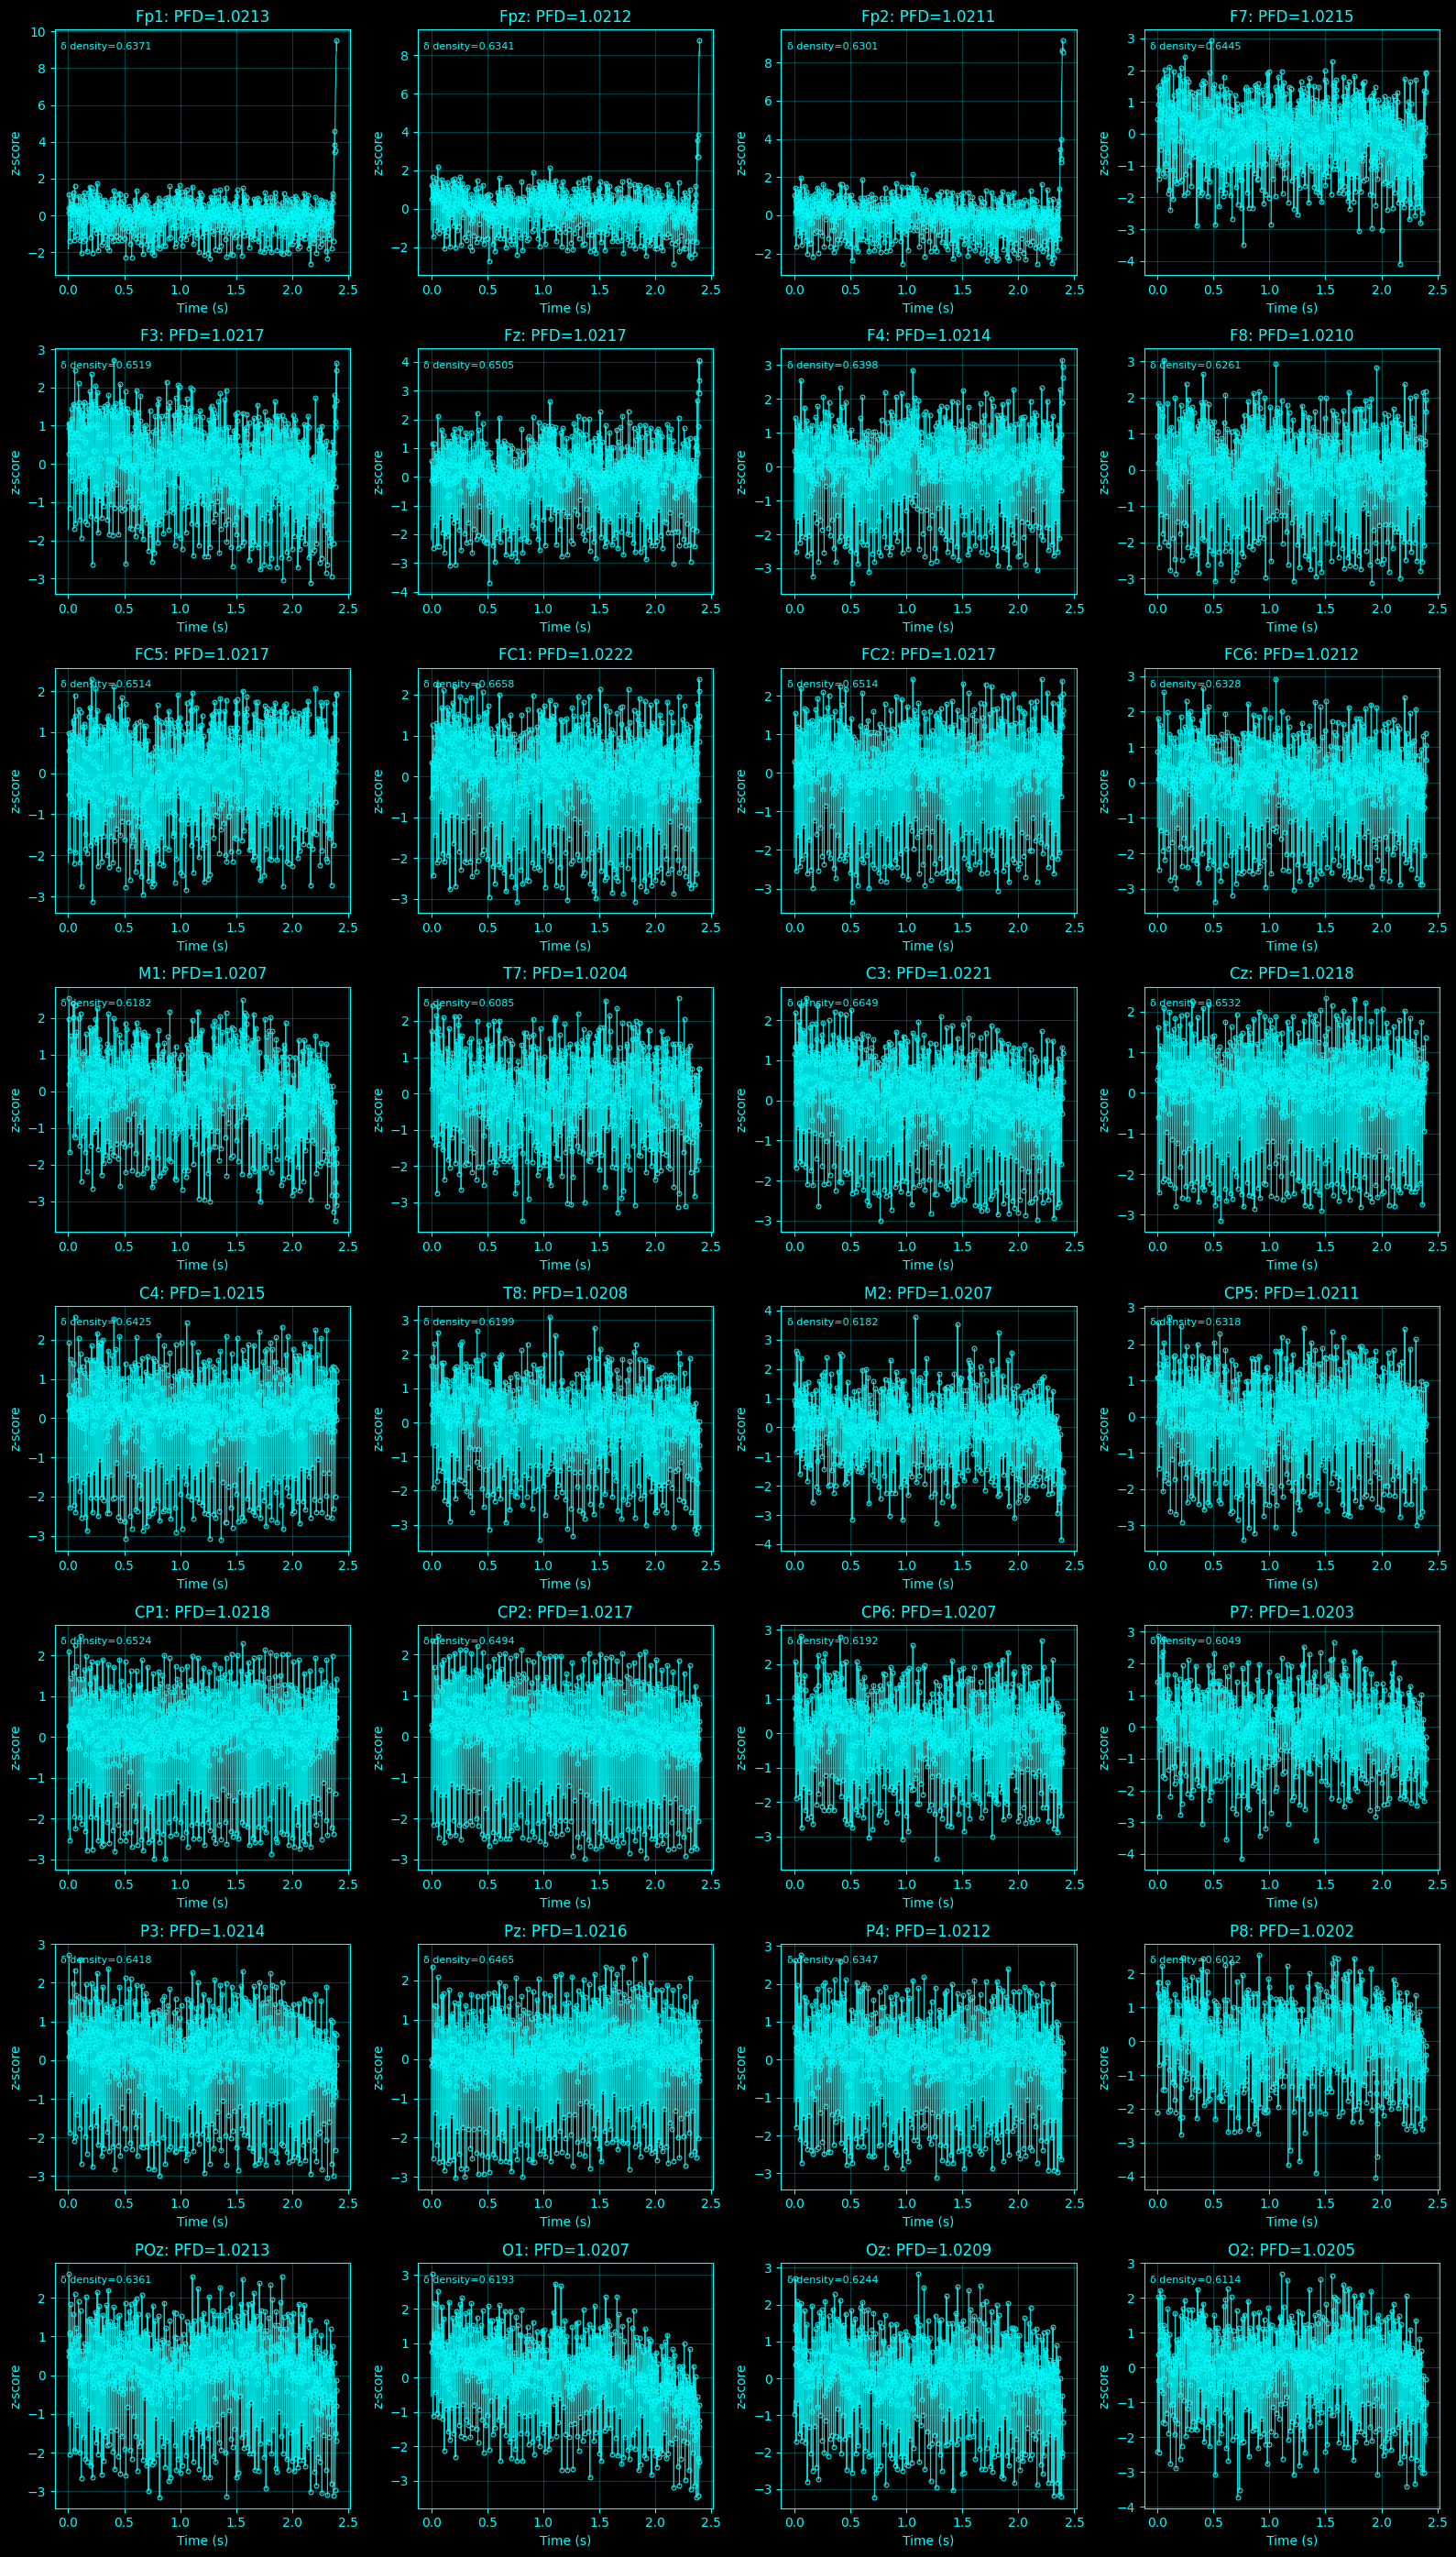

All-channel Petrosian diagnostic plot saved to: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_petrosian/all_channels_petrosian_sign_change_diagnostics.png


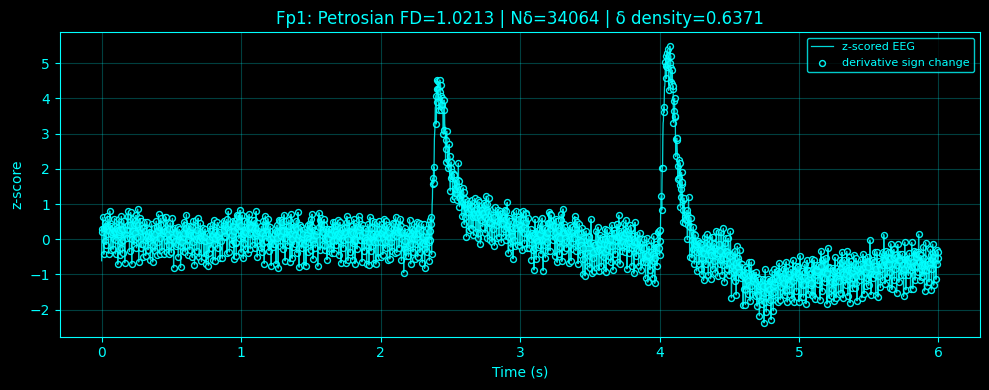

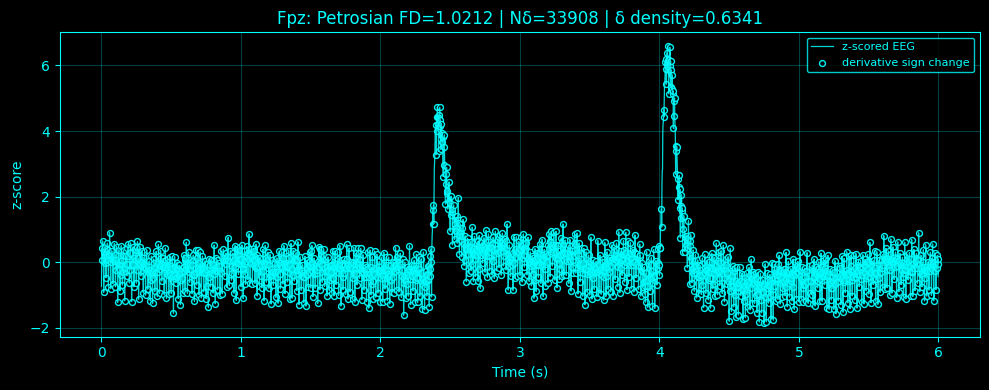

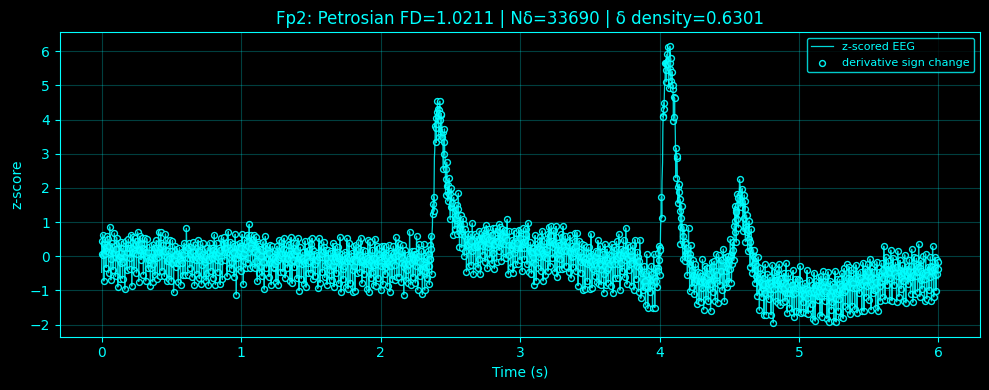

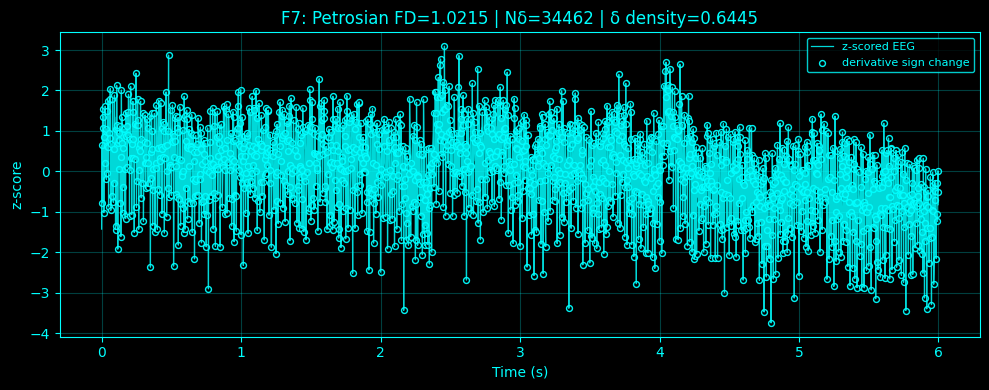

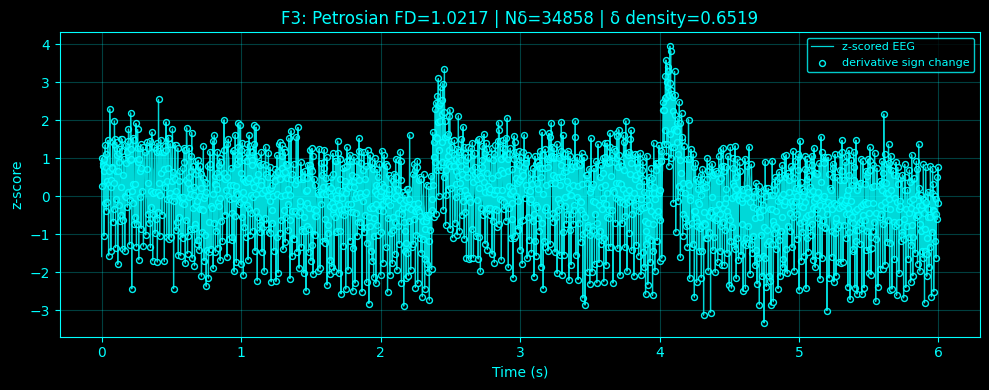

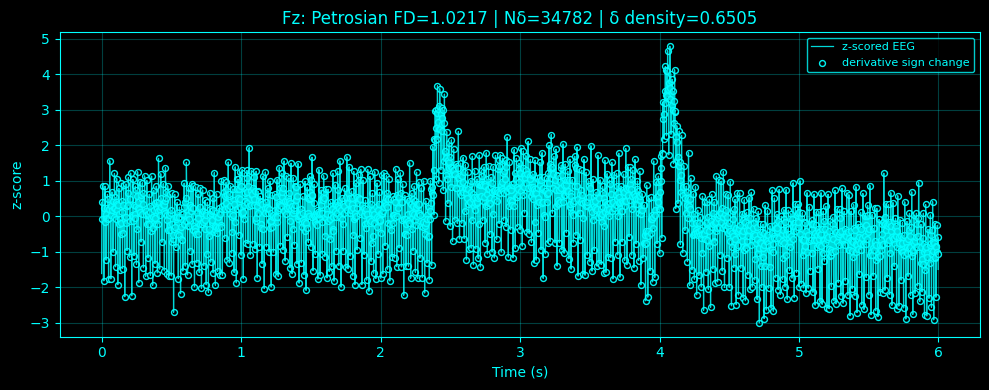

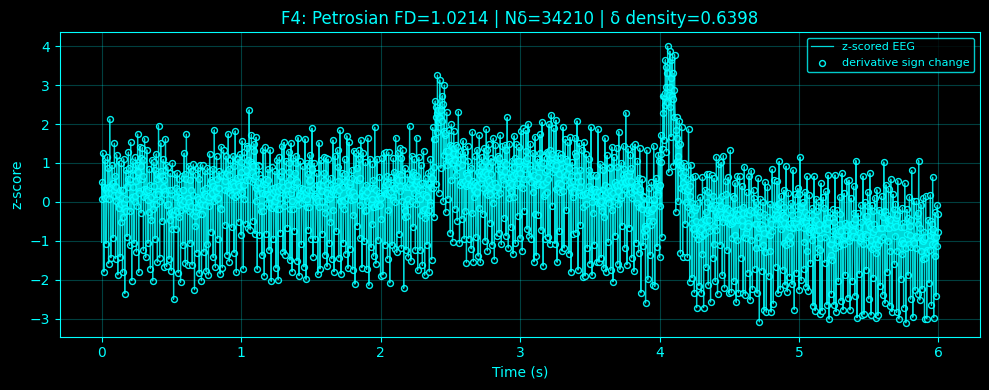

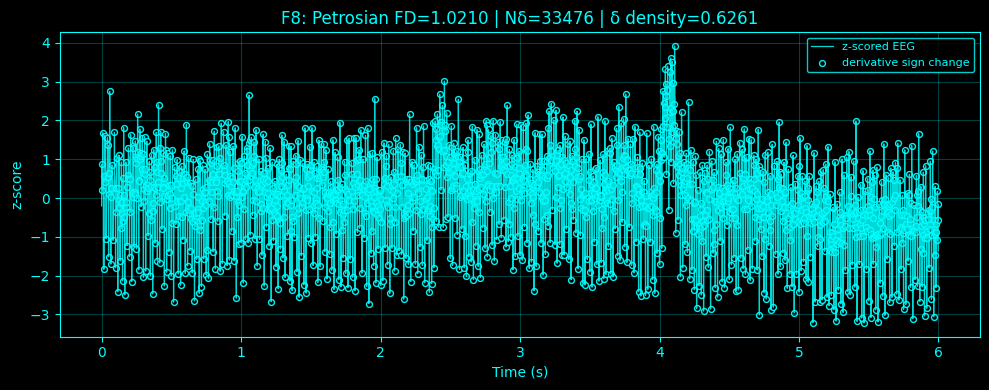

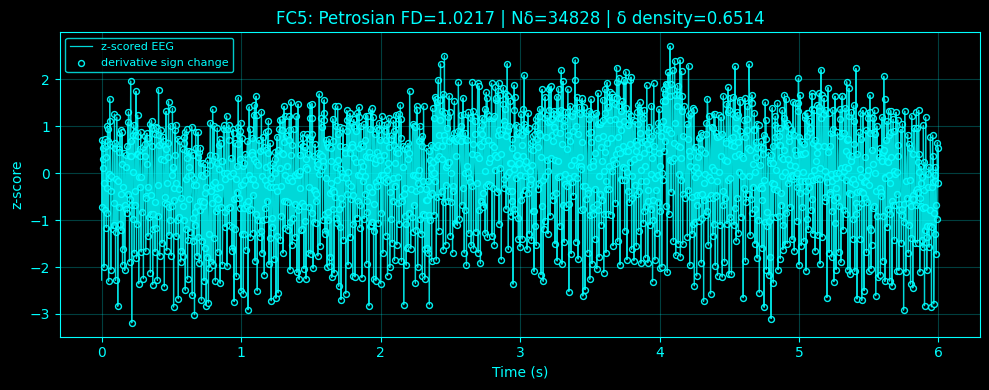

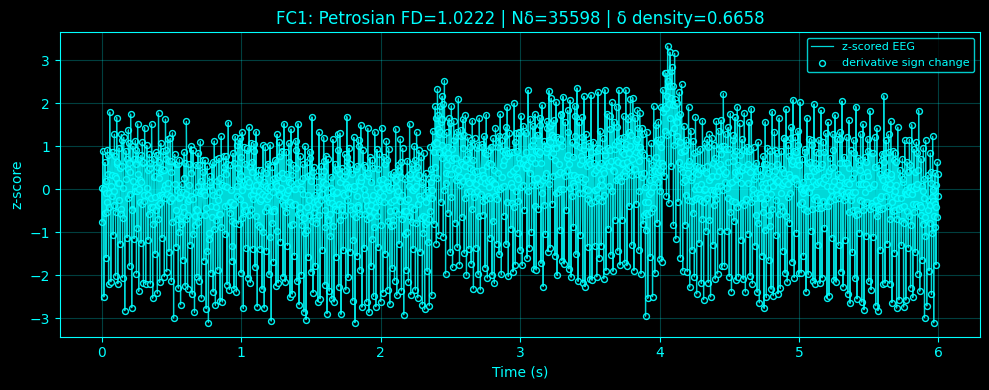

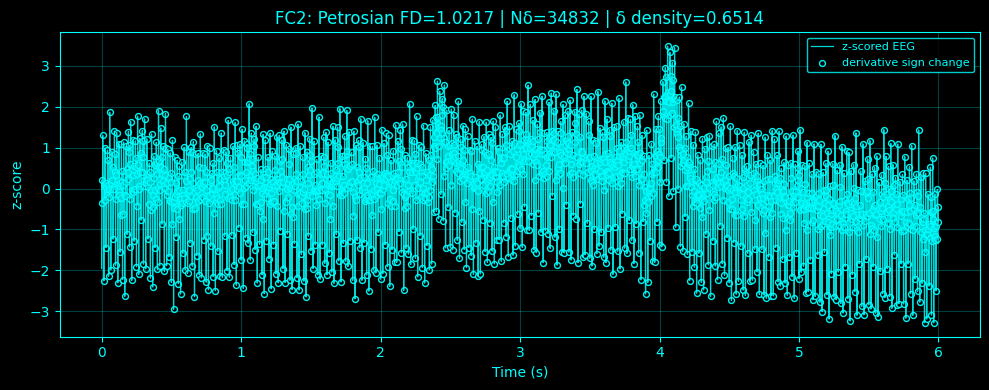

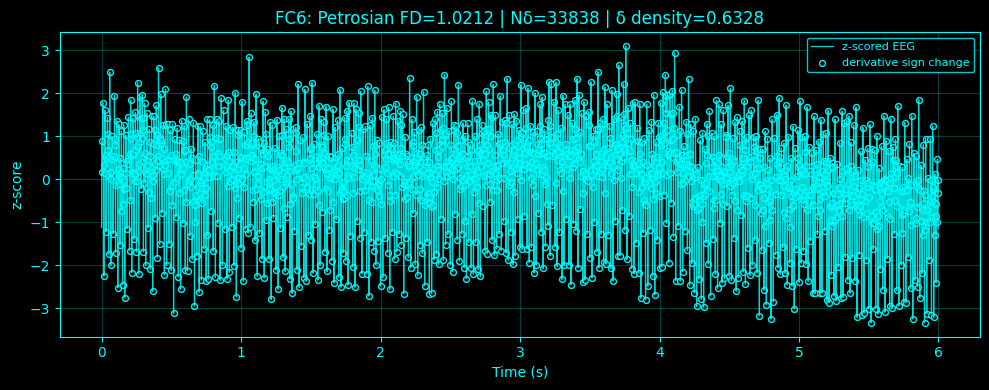

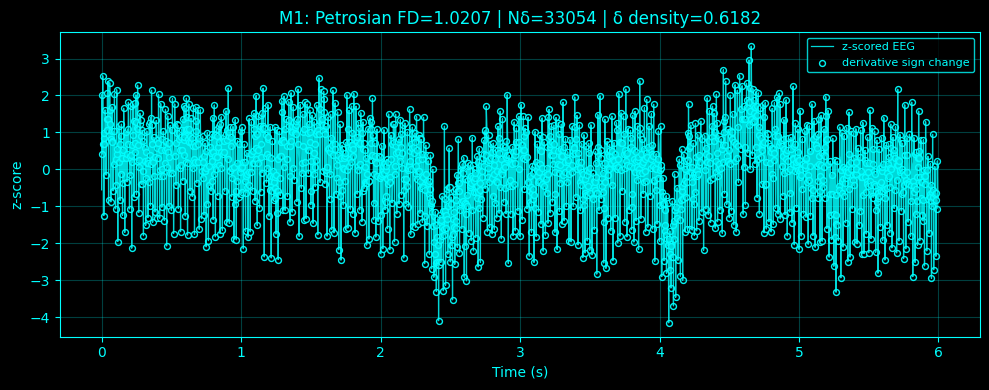

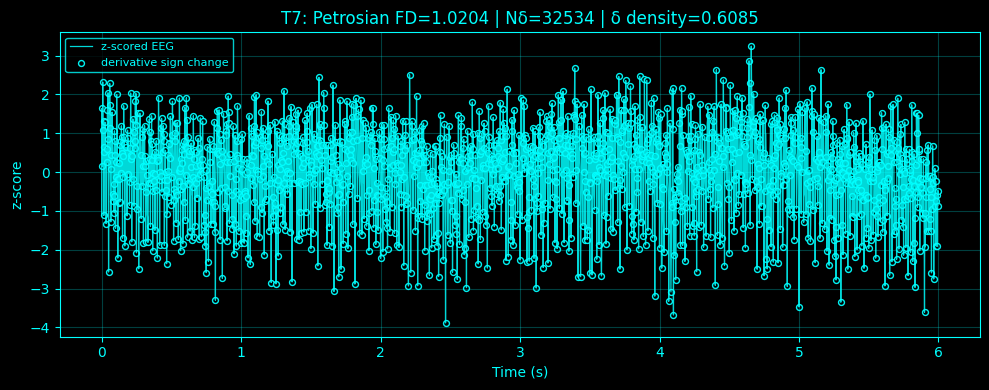

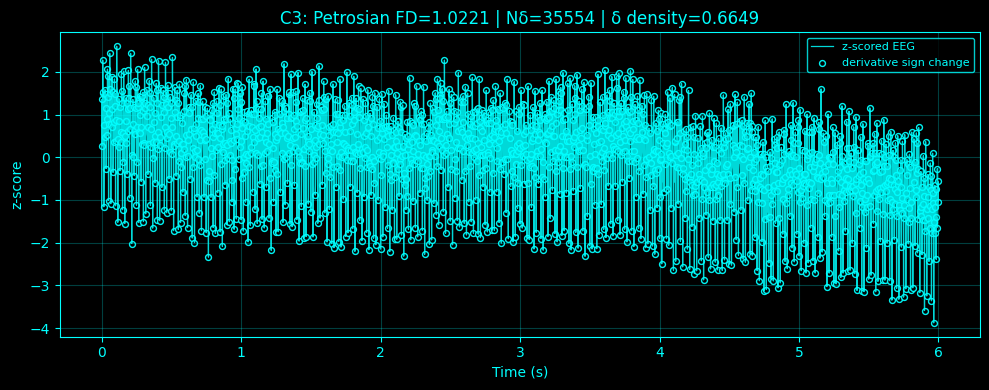

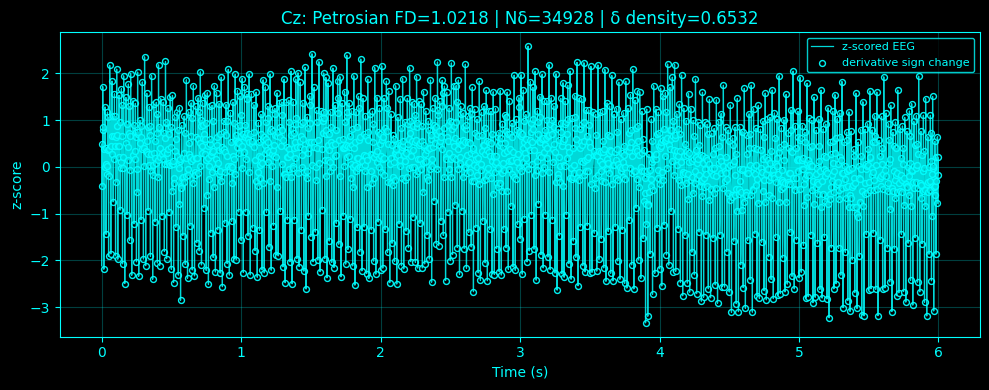

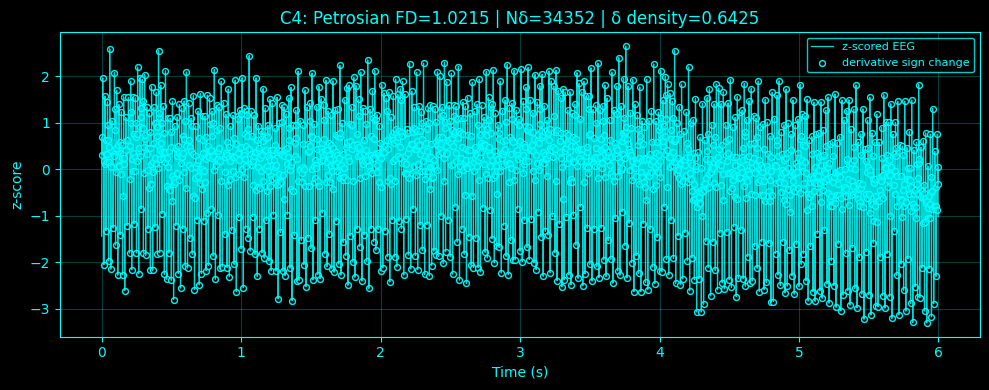

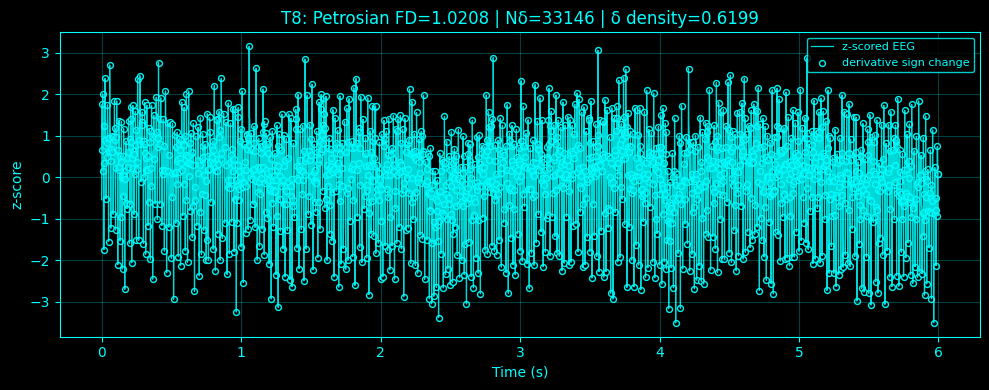

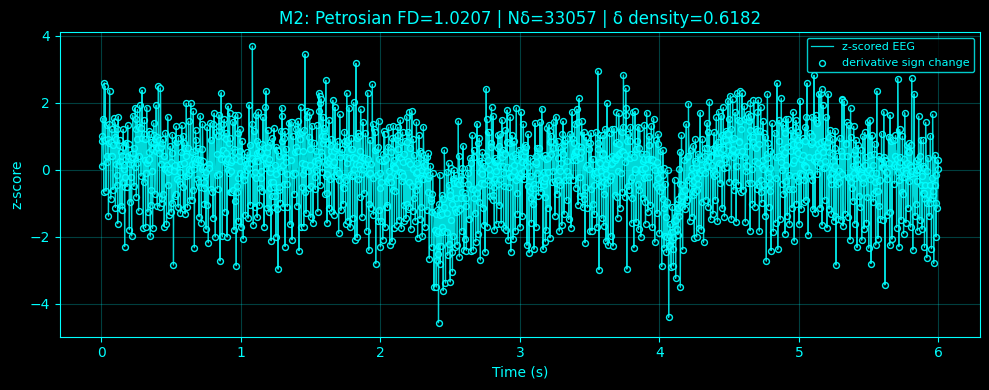

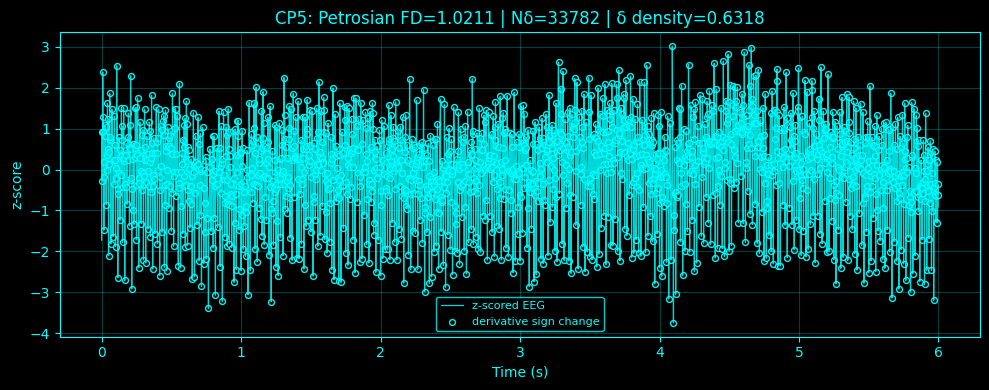

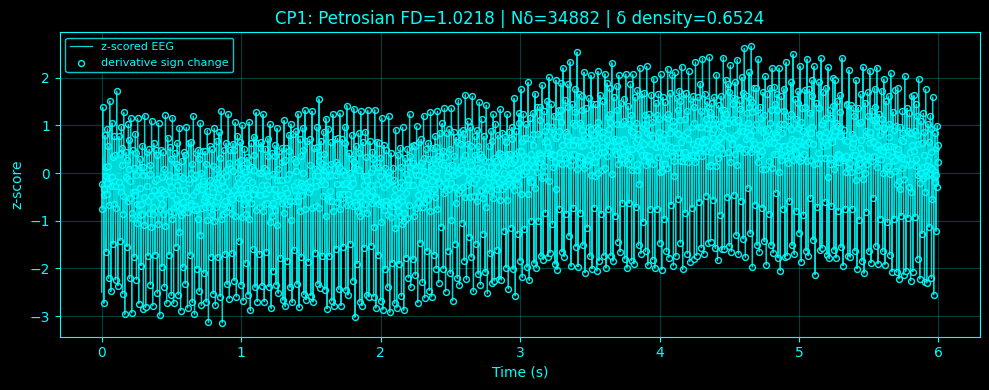

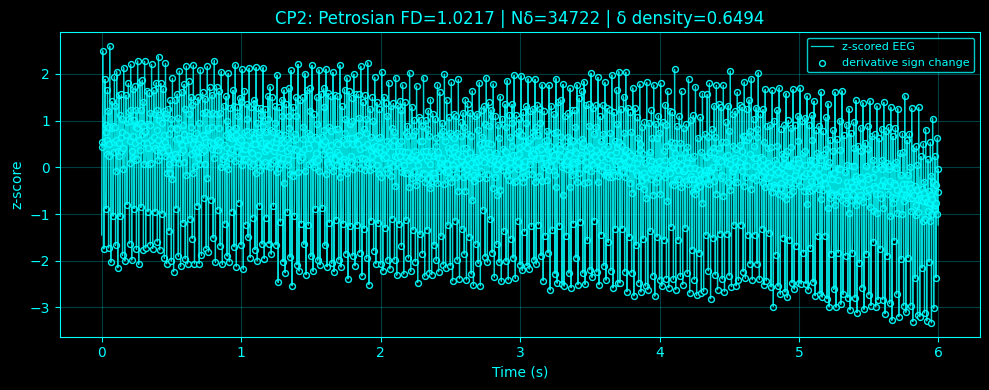

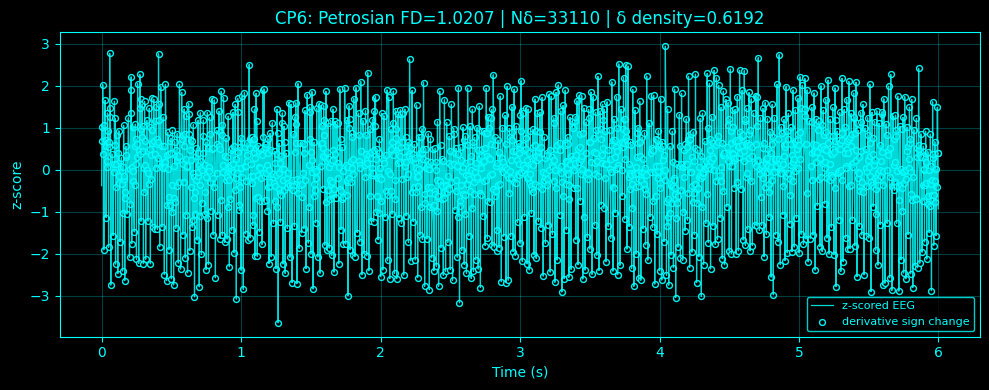

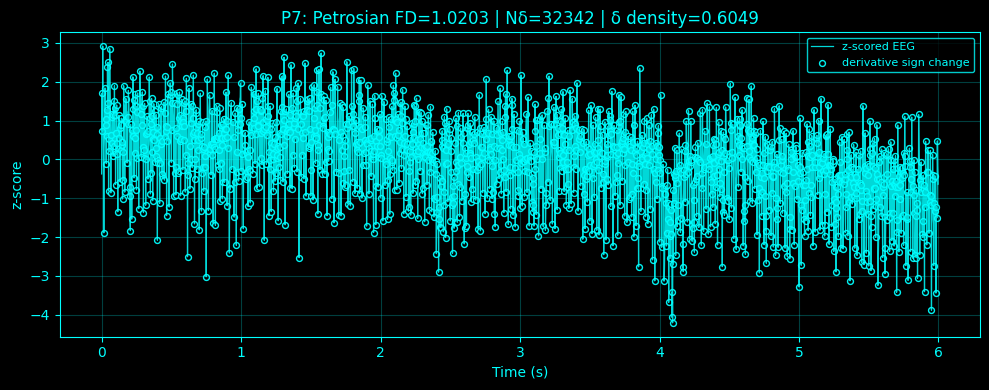

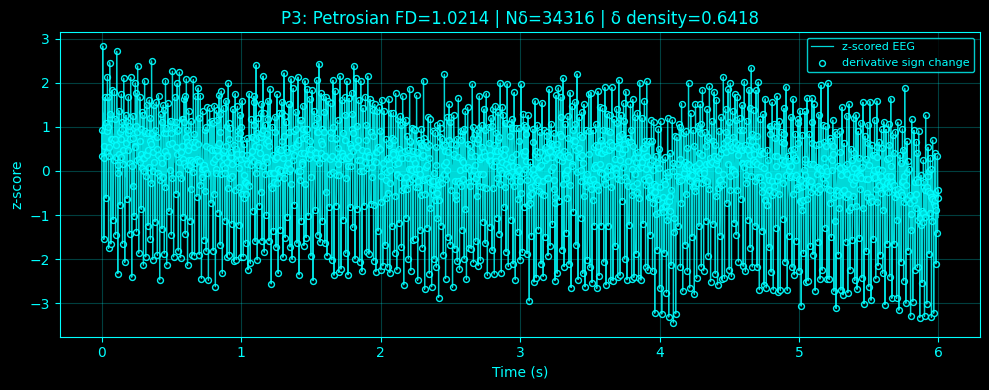

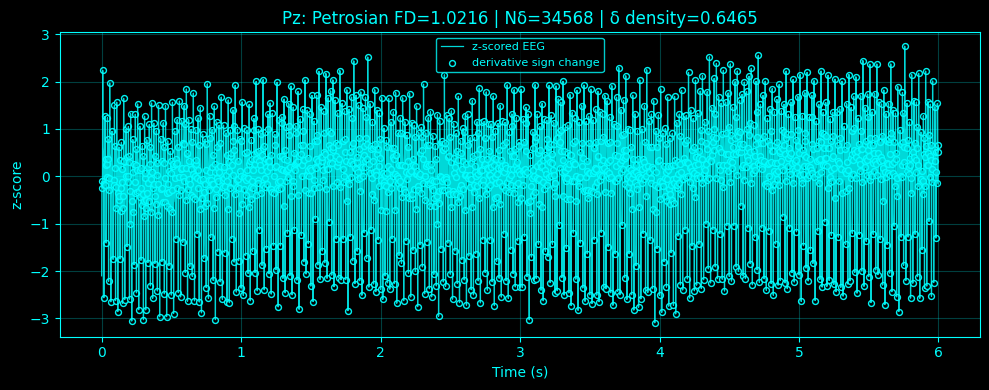

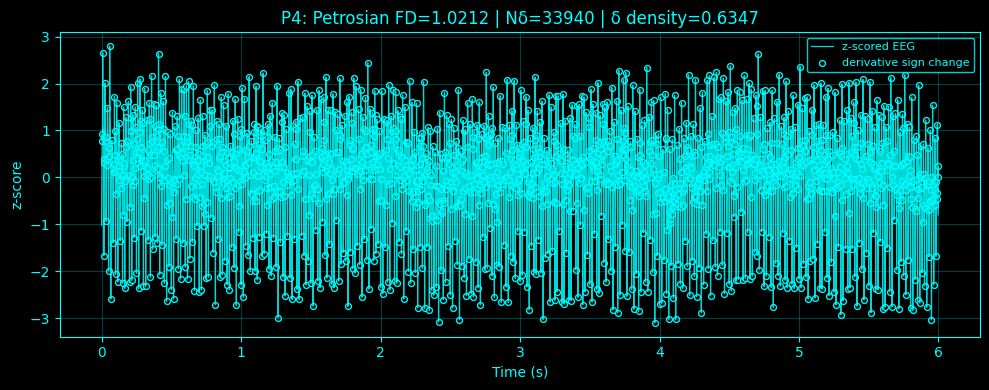

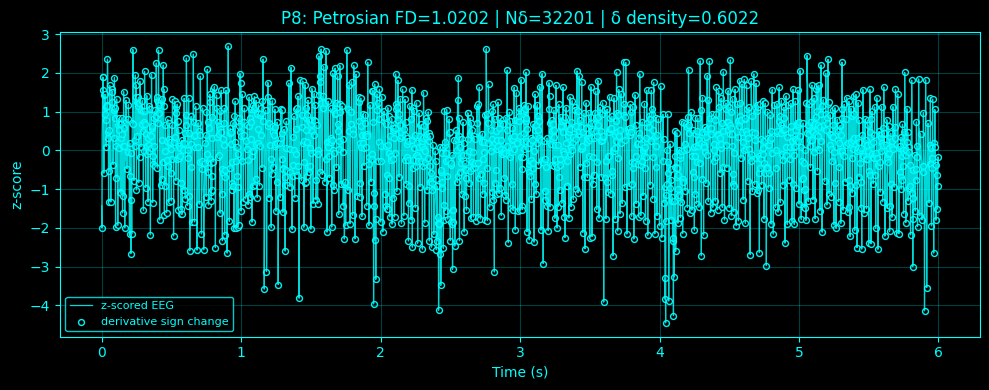

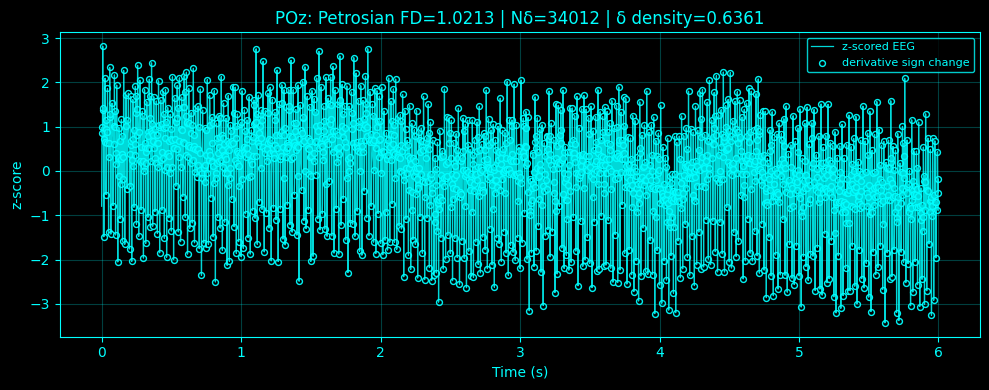

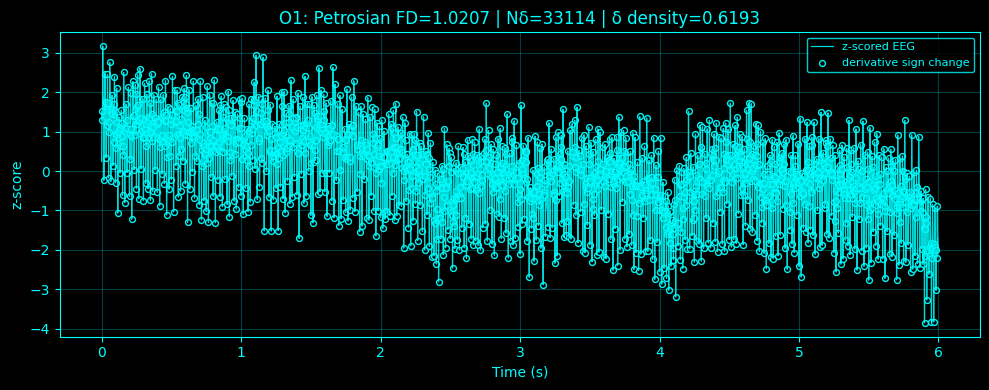

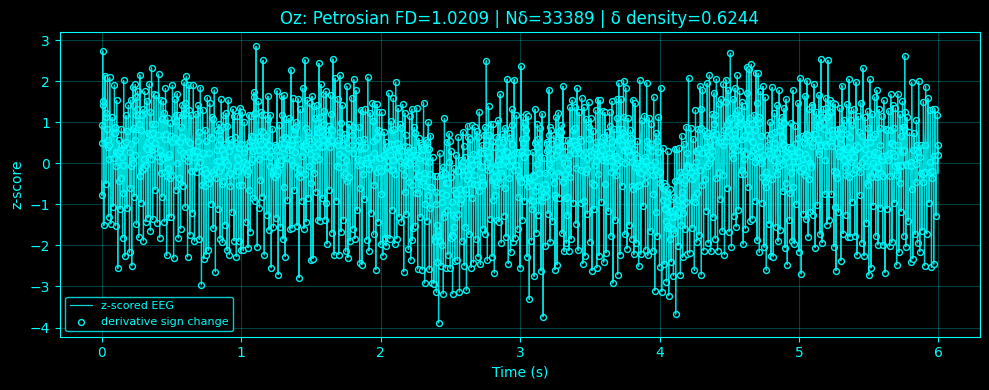

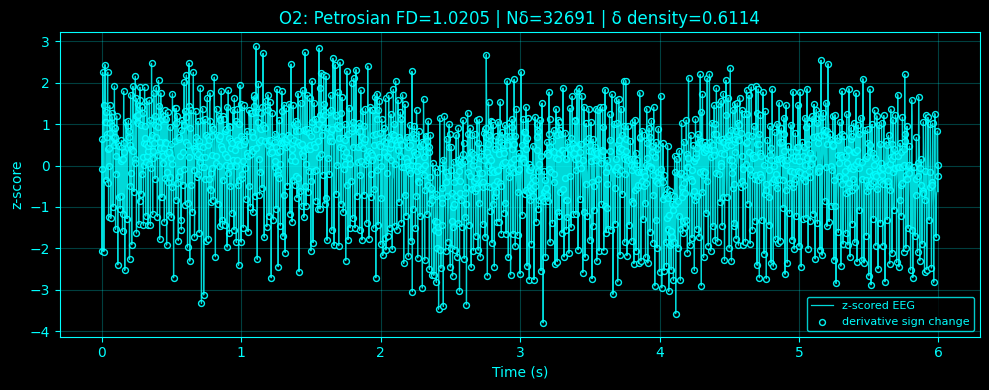

Per-channel Petrosian diagnostic plots saved to: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_petrosian/per_channel_petrosian_diagnostics


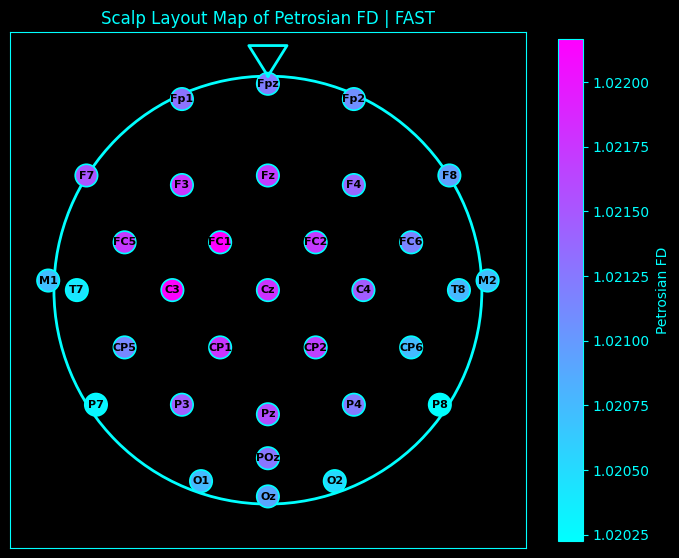

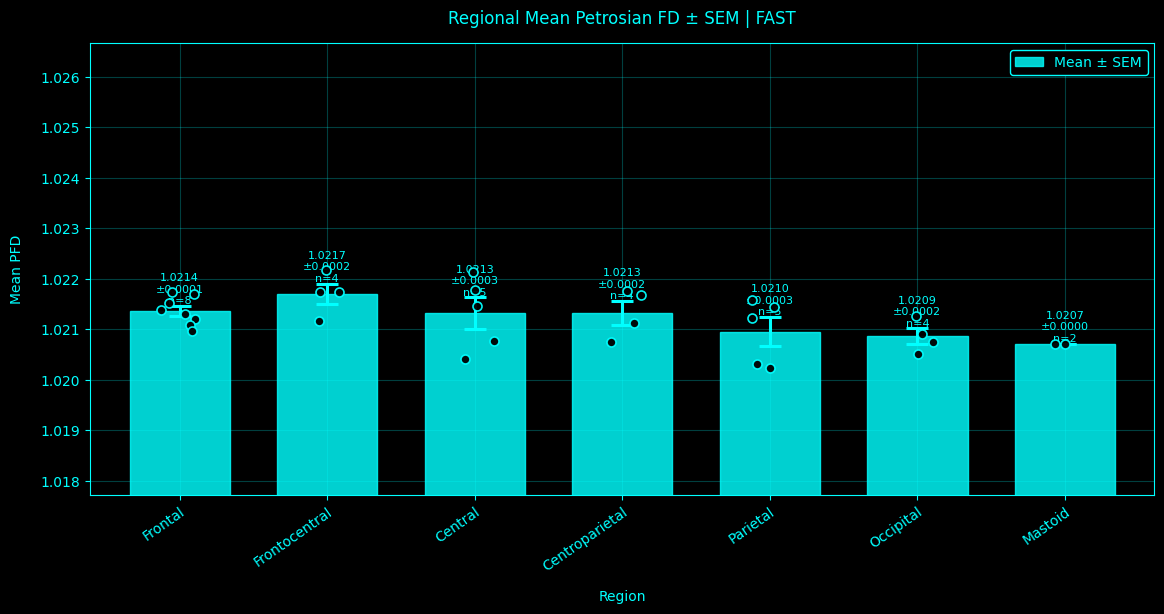

Regional summary plot saved to: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_petrosian/expert_plots_fast/regional_petrosian_fd_summary.png
Regional summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_petrosian/expert_plots_fast/regional_petrosian_fd_summary.csv
Regional channel-point CSV: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_petrosian/expert_plots_fast/regional_petrosian_fd_channel_points.csv


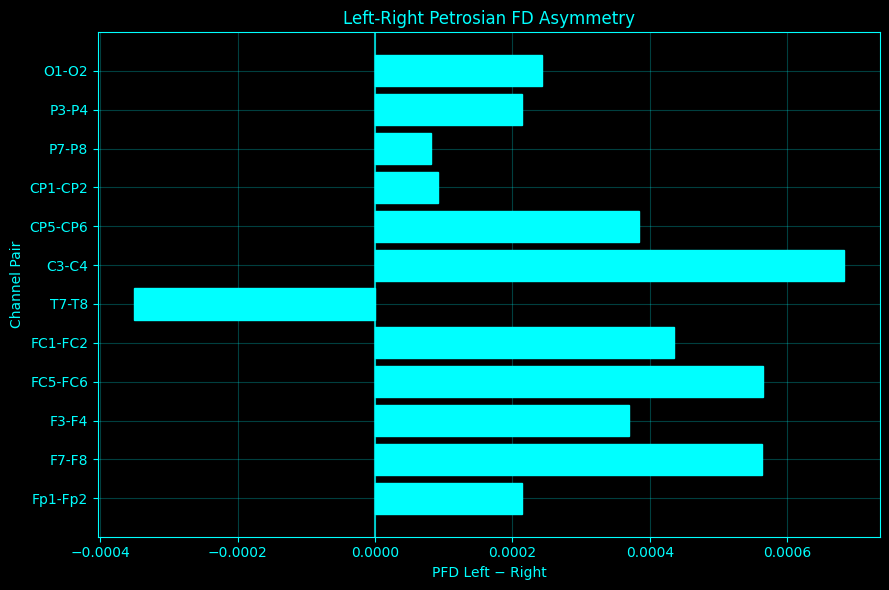

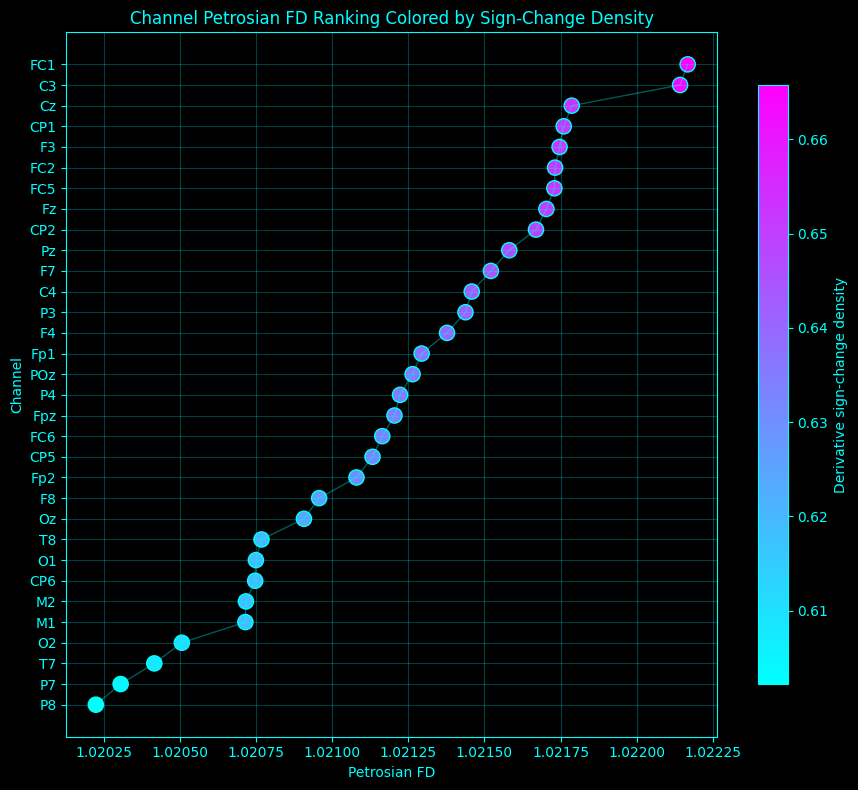

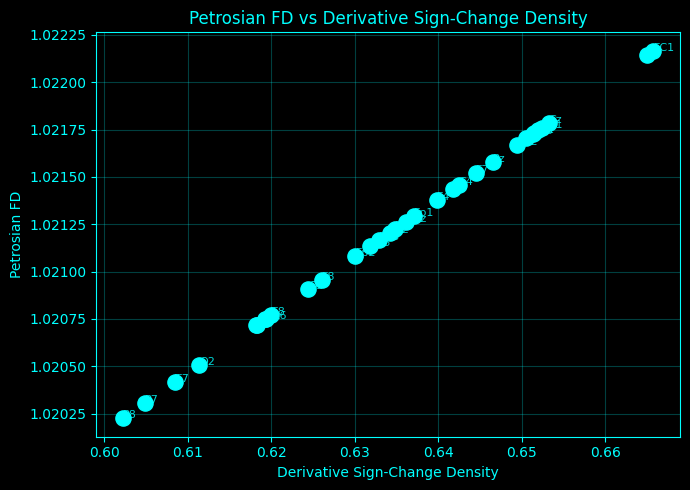

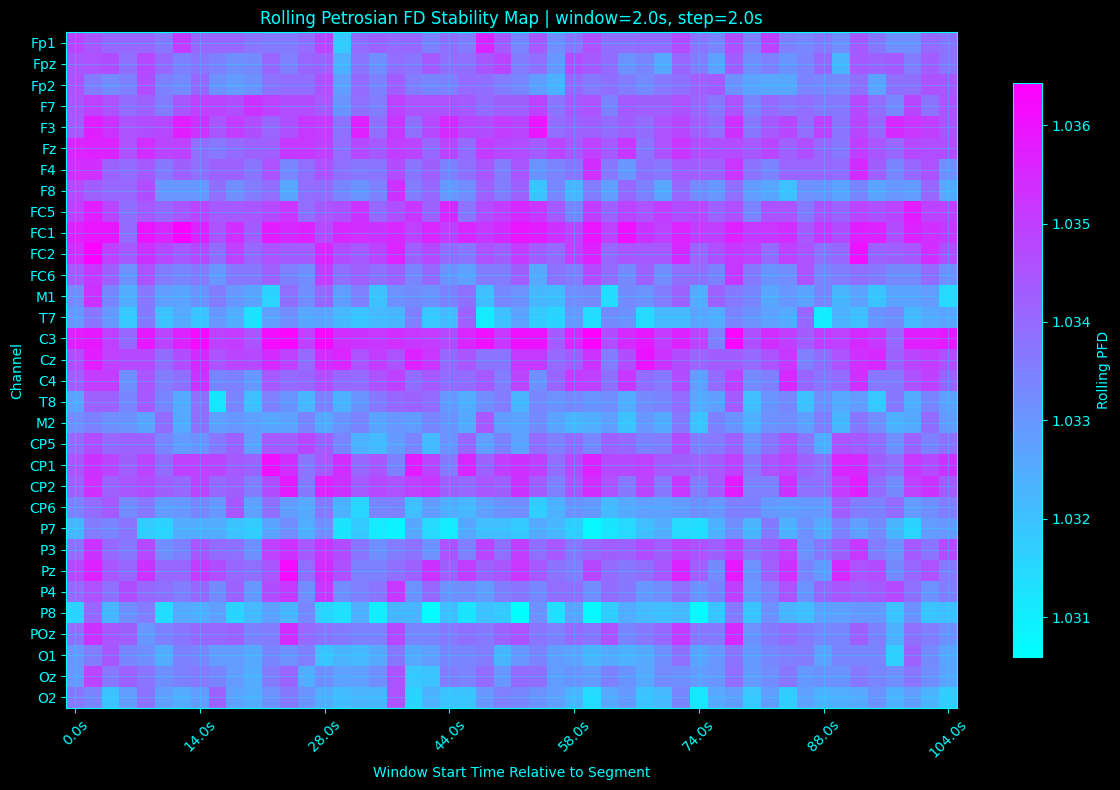

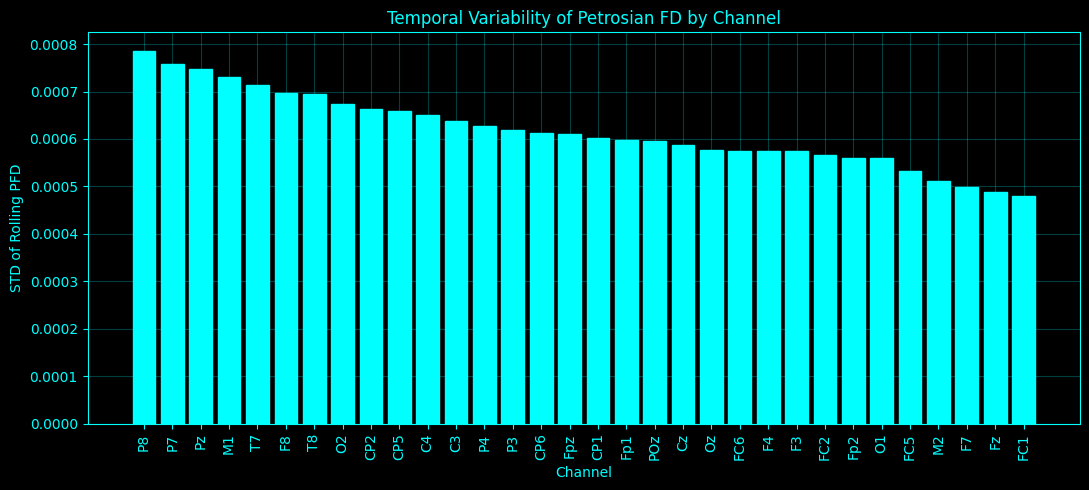

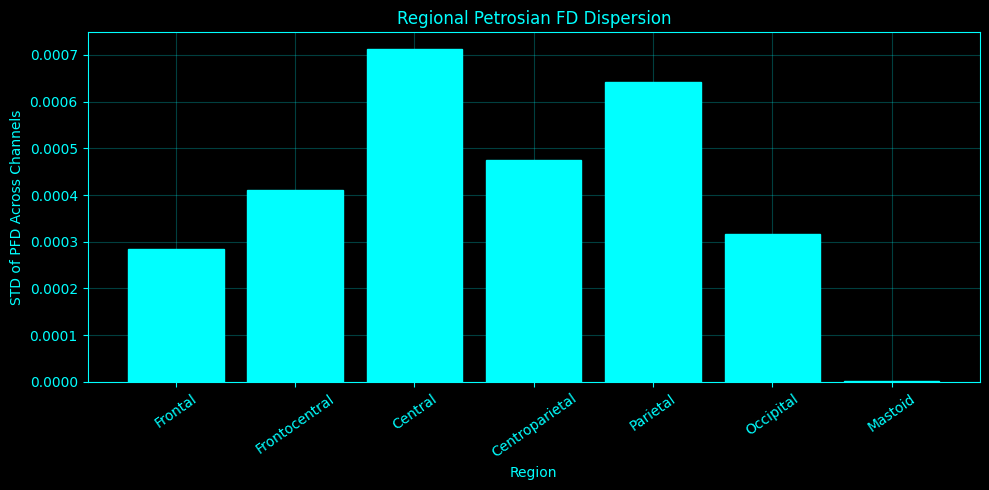

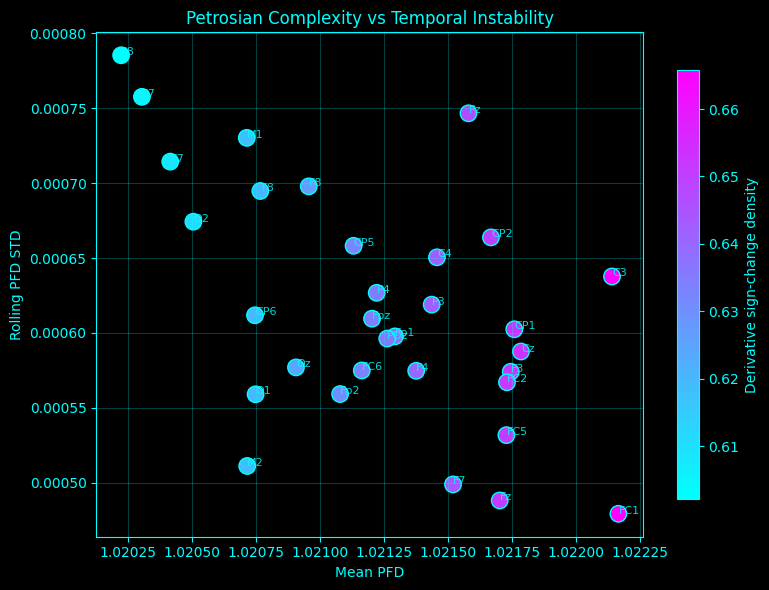


Expert plots saved to: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_petrosian/expert_plots_fast
Regional summary: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_petrosian/expert_plots_fast/regional_petrosian_fd_summary.csv
Asymmetry CSV: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_petrosian/expert_plots_fast/left_right_petrosian_fd_asymmetry.csv
Rolling PFD CSV: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_petrosian/expert_plots_fast/rolling_petrosian_fd_by_channel.csv
Rolling derivative density CSV: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_petrosian/expert_plots_fast/rolling_petrosian_delta_density_by_channel.csv
Temporal variability CSV: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_petrosian/expert_plots_fast/rolling_petrosian_fd_temporal_variability.csv

Saved outputs to: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_petrosian
S

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")
out_dir = os.path.join(base_dir, "fractal_dimension_petrosian")
os.makedirs(out_dir, exist_ok=True)

# Same segment used in your recent analyses
sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_idx = int(start_time * sampling_rate)
end_idx   = int(end_time * sampling_rate)

eeg_channels = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

# -------------------------------------------------------
# SPEED MODE
# -------------------------------------------------------
# Options:
#   "normal"    = highest fidelity
#   "fast"      = faster, mild downsampling/truncation
#   "ultrafast" = fastest exploratory scan
MODE = "fast"

MODE_CONFIGS = {
    "normal": {
        "decimate": 1,
        "max_samples": None,
        "rolling_window_sec": 2.0,
        "rolling_step_sec": 1.0,
        "rolling_max_windows": 100,
        "expert_plots": True,
    },
    "fast": {
        "decimate": 2,
        "max_samples": 60000,
        "rolling_window_sec": 2.0,
        "rolling_step_sec": 2.0,
        "rolling_max_windows": 50,
        "expert_plots": True,
    },
    "ultrafast": {
        "decimate": 5,
        "max_samples": 20000,
        "rolling_window_sec": 1.0,
        "rolling_step_sec": 3.0,
        "rolling_max_windows": 20,
        "expert_plots": True,
    },
}

if MODE not in MODE_CONFIGS:
    raise ValueError(f"Unknown MODE={MODE}. Use one of: {list(MODE_CONFIGS)}")

mode_cfg = MODE_CONFIGS[MODE]

decimate = mode_cfg["decimate"]
max_samples = mode_cfg["max_samples"]

ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

print(f"\nRunning Petrosian FD in {MODE.upper()} mode")
print(f"decimate={decimate}, max_samples={max_samples}")

# -------------------------------------------------------
# STYLE HELPER
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.25, color=ACCENT)
    ax.tick_params(colors=ACCENT)

    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# LOAD EEG
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)

if EEG_data.ndim != 2:
    raise ValueError(f"Expected 2D EEG array, got shape {EEG_data.shape}")

# Handle either (time, channels) or (channels, time)
if EEG_data.shape[1] == len(eeg_channels):
    EEG_segment = EEG_data[start_idx:end_idx, :]
elif EEG_data.shape[0] == len(eeg_channels):
    EEG_segment = EEG_data[:, start_idx:end_idx].T
else:
    raise ValueError(f"Unexpected EEG shape: {EEG_data.shape}")

n_time, n_channels = EEG_segment.shape
print(f"Loaded EEG segment: {n_time} samples x {n_channels} channels")
print(f"Segment: [{start_time}, {end_time}] sec")

# -------------------------------------------------------
# APPLY SPEED MODE PREPROCESSING
# -------------------------------------------------------
effective_sampling_rate = sampling_rate

if decimate > 1:
    EEG_segment = EEG_segment[::decimate, :]
    effective_sampling_rate = sampling_rate / decimate

if max_samples is not None and EEG_segment.shape[0] > max_samples:
    EEG_segment = EEG_segment[:max_samples, :]

n_time, n_channels = EEG_segment.shape

print(f"After {MODE.upper()} mode preprocessing:")
print(f"  Segment shape: {n_time} samples x {n_channels} channels")
print(f"  Effective sampling rate: {effective_sampling_rate:.2f} Hz")
print(f"  Effective duration: {n_time / effective_sampling_rate:.2f} sec")

# -------------------------------------------------------
# PETROSIAN FRACTAL DIMENSION
# -------------------------------------------------------
def derivative_sign_changes(x):
    """
    Count sign changes in the first derivative.

    This is the N_delta term used by Petrosian FD.
    Zeros are handled by forward/backward filling derivative signs
    so flat samples do not create artificial sign changes.
    """
    x = np.asarray(x, dtype=float)

    if len(x) < 3:
        return 0

    dx = np.diff(x)
    signs = np.sign(dx)

    # Replace zeros with nearest nonzero sign to avoid false transitions.
    # Forward fill.
    for i in range(1, len(signs)):
        if signs[i] == 0:
            signs[i] = signs[i - 1]

    # Backward fill for leading zeros.
    for i in range(len(signs) - 2, -1, -1):
        if signs[i] == 0:
            signs[i] = signs[i + 1]

    # If all signs are zero, no derivative sign changes.
    if np.all(signs == 0):
        return 0

    return int(np.sum(signs[1:] * signs[:-1] < 0))


def petrosian_fd(x):
    """
    Compute Petrosian Fractal Dimension for a 1D time series.

    Formula:
        PFD = log10(N) / [log10(N) + log10(N / (N + 0.4 * N_delta))]

    where:
        N       = number of samples
        N_delta = number of sign changes in the first derivative

    PFD is especially fast and useful for EEG waveform-complexity screening.
    """
    x = np.asarray(x, dtype=float)
    N = len(x)

    if N < 3:
        return np.nan, {
            "n_samples": N,
            "n_delta": np.nan,
            "delta_density": np.nan,
            "derivative_zero_crossing_rate_hz": np.nan,
        }

    n_delta = derivative_sign_changes(x)

    pfd = np.log10(N) / (
        np.log10(N) + np.log10(N / (N + 0.4 * n_delta + 1e-12))
    )

    delta_density = n_delta / max(N - 2, 1)
    derivative_zero_crossing_rate_hz = np.nan

    return pfd, {
        "n_samples": N,
        "n_delta": n_delta,
        "delta_density": delta_density,
        "derivative_zero_crossing_rate_hz": derivative_zero_crossing_rate_hz,
    }


def petrosian_fd_with_rate(x, fs):
    """
    Petrosian FD plus derivative sign-change rate in Hz.
    """
    pfd, diag = petrosian_fd(x)

    duration_sec = len(x) / fs if fs > 0 else np.nan

    if np.isfinite(duration_sec) and duration_sec > 0 and np.isfinite(diag["n_delta"]):
        diag["derivative_zero_crossing_rate_hz"] = diag["n_delta"] / duration_sec
    else:
        diag["derivative_zero_crossing_rate_hz"] = np.nan

    return pfd, diag


# -------------------------------------------------------
# RUN PETROSIAN FD PER CHANNEL
# -------------------------------------------------------
rows = {}
diagnostic_rows = []

for ch_idx, ch_name in enumerate(eeg_channels):
    x = EEG_segment[:, ch_idx].astype(float)
    x = (x - np.mean(x)) / (np.std(x) + 1e-12)

    pfd, diag = petrosian_fd_with_rate(x, effective_sampling_rate)

    rows[ch_name] = {
        "channel": ch_name,
        "petrosian_fd": pfd,
        "n_samples": diag["n_samples"],
        "n_delta": diag["n_delta"],
        "delta_density": diag["delta_density"],
        "derivative_zero_crossing_rate_hz": diag["derivative_zero_crossing_rate_hz"],
    }

    diagnostic_rows.append(rows[ch_name])

results_df = (
    pd.DataFrame(diagnostic_rows)
    .sort_values("petrosian_fd", ascending=False)
    .reset_index(drop=True)
)

csv_path = os.path.join(out_dir, "petrosian_fd_summary.csv")
results_df.to_csv(csv_path, index=False)

print("\nPetrosian Fractal Dimensions:")
print(results_df)

# -------------------------------------------------------
# SAVE DIAGNOSTIC TABLE
# -------------------------------------------------------
diagnostics_df = results_df.copy()

diagnostics_csv_path = os.path.join(out_dir, "petrosian_fd_diagnostics.csv")
diagnostics_df.to_csv(diagnostics_csv_path, index=False)

print(f"\nDiagnostics CSV: {diagnostics_csv_path}")

# -------------------------------------------------------
# PLOT 1: FIXED PFD BY CHANNEL PLOT
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(13, 5.8), facecolor=BG)
style_ax(ax)

plot_df = results_df.copy().sort_values("petrosian_fd", ascending=False).reset_index(drop=True)

x = np.arange(len(plot_df))
y = plot_df["petrosian_fd"].to_numpy(dtype=float)

y_min = np.nanmin(y)
y_max = np.nanmax(y)
y_range = y_max - y_min

if not np.isfinite(y_range) or y_range <= 0:
    y_range = 0.001

pad = max(0.0005, y_range * 0.35)
baseline = y_min - pad * 0.6

# Lollipop stems make tiny PFD differences visible without implying a zero baseline
ax.vlines(
    x,
    baseline,
    y,
    color=ACCENT,
    linewidth=1.8,
    alpha=0.75
)

ax.scatter(
    x,
    y,
    s=85,
    facecolors=BG,
    edgecolors=ACCENT,
    linewidths=1.8,
    zorder=4,
    label="Petrosian FD"
)

mean_pfd = np.nanmean(y)

ax.axhline(
    mean_pfd,
    color=ACCENT,
    linestyle="--",
    linewidth=1.4,
    alpha=0.75,
    label=f"Mean={mean_pfd:.5f}"
)

# Label strongest and weakest channels
top_n = min(4, len(plot_df))
label_indices = list(range(top_n)) + list(range(len(plot_df) - top_n, len(plot_df)))

for i in sorted(set(label_indices)):
    ax.text(
        x[i],
        y[i] + pad * 0.12,
        f"{y[i]:.5f}",
        ha="center",
        va="bottom",
        fontsize=7,
        color=ACCENT,
        rotation=90
    )

ax.set_ylim(baseline, y_max + pad * 1.3)

ax.set_title(f"Petrosian Fractal Dimension by Channel | {MODE.upper()}", pad=12)
ax.set_xlabel("Channel")
ax.set_ylabel("PFD")

ax.set_xticks(x)
ax.set_xticklabels(plot_df["channel"], rotation=90)

ax.legend(loc="best", framealpha=1.0)

bar_path = os.path.join(out_dir, "petrosian_fd_barplot.png")
plt.tight_layout()
plt.savefig(bar_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 2: ALL-CHANNEL DERIVATIVE SIGN-CHANGE DIAGNOSTICS
# -------------------------------------------------------
n_cols = 4
n_rows = int(np.ceil(len(eeg_channels) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4 * n_cols, 3.5 * n_rows),
    facecolor=BG
)

axes = axes.flatten()

samples_to_plot = min(1200, n_time)
time_axis = np.arange(samples_to_plot) / effective_sampling_rate

for ax_idx, ch_name in enumerate(eeg_channels):
    ax = axes[ax_idx]
    style_ax(ax)

    ch_idx = eeg_channels.index(ch_name)

    x = EEG_segment[:samples_to_plot, ch_idx].astype(float)
    x = (x - np.mean(x)) / (np.std(x) + 1e-12)

    dx = np.diff(x)
    sign_change_idx = []

    if len(dx) >= 2:
        signs = np.sign(dx)

        for i in range(1, len(signs)):
            if signs[i] == 0:
                signs[i] = signs[i - 1]

        for i in range(len(signs) - 2, -1, -1):
            if signs[i] == 0:
                signs[i] = signs[i + 1]

        sign_change_idx = np.where(signs[1:] * signs[:-1] < 0)[0] + 1

    pfd_val = rows[ch_name]["petrosian_fd"]
    delta_density = rows[ch_name]["delta_density"]

    ax.plot(
        time_axis,
        x,
        color=ACCENT,
        linewidth=0.8,
        alpha=0.85,
        label="signal"
    )

    if len(sign_change_idx) > 0:
        valid_idx = sign_change_idx[sign_change_idx < samples_to_plot]
        ax.scatter(
            time_axis[valid_idx],
            x[valid_idx],
            s=12,
            facecolors=BG,
            edgecolors=ACCENT,
            linewidths=0.8,
            alpha=0.95,
            label="d sign flip"
        )

    ax.set_title(f"{ch_name}: PFD={pfd_val:.4f}")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("z-score")

    if np.isfinite(delta_density):
        ax.text(
            0.02,
            0.95,
            f"δ density={delta_density:.4f}",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=8,
            color=ACCENT
        )

# Turn off unused axes if any
for j in range(len(eeg_channels), len(axes)):
    axes[j].axis("off")

all_diag_path = os.path.join(out_dir, "all_channels_petrosian_sign_change_diagnostics.png")
plt.tight_layout()
plt.savefig(all_diag_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

print(f"All-channel Petrosian diagnostic plot saved to: {all_diag_path}")

# -------------------------------------------------------
# OPTIONAL: SAVE ONE DIAGNOSTIC PLOT PER CHANNEL
# -------------------------------------------------------
per_channel_dir = os.path.join(out_dir, "per_channel_petrosian_diagnostics")
os.makedirs(per_channel_dir, exist_ok=True)

samples_to_plot = min(3000, n_time)
time_axis = np.arange(samples_to_plot) / effective_sampling_rate

for ch_name in eeg_channels:
    ch_idx = eeg_channels.index(ch_name)

    x = EEG_segment[:samples_to_plot, ch_idx].astype(float)
    x = (x - np.mean(x)) / (np.std(x) + 1e-12)

    dx = np.diff(x)
    sign_change_idx = []

    if len(dx) >= 2:
        signs = np.sign(dx)

        for i in range(1, len(signs)):
            if signs[i] == 0:
                signs[i] = signs[i - 1]

        for i in range(len(signs) - 2, -1, -1):
            if signs[i] == 0:
                signs[i] = signs[i + 1]

        sign_change_idx = np.where(signs[1:] * signs[:-1] < 0)[0] + 1

    pfd_val = rows[ch_name]["petrosian_fd"]
    n_delta = rows[ch_name]["n_delta"]
    delta_density = rows[ch_name]["delta_density"]

    fig, ax = plt.subplots(figsize=(10, 4), facecolor=BG)
    style_ax(ax)

    ax.plot(
        time_axis,
        x,
        color=ACCENT,
        linewidth=0.9,
        alpha=0.85,
        label="z-scored EEG"
    )

    if len(sign_change_idx) > 0:
        valid_idx = sign_change_idx[sign_change_idx < samples_to_plot]

        ax.scatter(
            time_axis[valid_idx],
            x[valid_idx],
            s=18,
            facecolors=BG,
            edgecolors=ACCENT,
            linewidths=1.0,
            alpha=0.95,
            label="derivative sign change"
        )

    ax.set_title(
        f"{ch_name}: Petrosian FD={pfd_val:.4f} | "
        f"Nδ={int(n_delta)} | δ density={delta_density:.4f}"
    )

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("z-score")
    ax.legend(fontsize=8)

    diag_path = os.path.join(per_channel_dir, f"{ch_name}_petrosian_diagnostic.png")
    plt.tight_layout()
    plt.savefig(diag_path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close()

print(f"Per-channel Petrosian diagnostic plots saved to: {per_channel_dir}")

# -------------------------------------------------------
# SAVE ALL VALUES
# -------------------------------------------------------
npz_path = os.path.join(out_dir, "petrosian_fd_values.npz")

save_dict = {
    "channels": np.asarray(eeg_channels),
    "petrosian_fd": np.asarray([rows[ch]["petrosian_fd"] for ch in eeg_channels], dtype=float),
    "n_delta": np.asarray([rows[ch]["n_delta"] for ch in eeg_channels], dtype=float),
    "delta_density": np.asarray([rows[ch]["delta_density"] for ch in eeg_channels], dtype=float),
    "derivative_zero_crossing_rate_hz": np.asarray(
        [rows[ch]["derivative_zero_crossing_rate_hz"] for ch in eeg_channels],
        dtype=float
    ),
}

np.savez(npz_path, **save_dict)

# -------------------------------------------------------
# ADDITIONAL PLOTS
# -------------------------------------------------------
if mode_cfg["expert_plots"]:

    expert_dir = os.path.join(out_dir, f"expert_plots_{MODE}")
    os.makedirs(expert_dir, exist_ok=True)

    pfd_map = dict(zip(results_df["channel"], results_df["petrosian_fd"]))
    delta_density_map = dict(zip(results_df["channel"], results_df["delta_density"]))
    n_delta_map = dict(zip(results_df["channel"], results_df["n_delta"]))

    # ---------------------------------------------------
    # PLOT 3: SCALP-LAYOUT PFD MAP
    # ---------------------------------------------------
    scalp_xy = {
        "Fp1": (-0.45, 1.00), "Fpz": (0.00, 1.08), "Fp2": (0.45, 1.00),
        "F7": (-0.95, 0.60), "F3": (-0.45, 0.55), "Fz": (0.00, 0.60),
        "F4": (0.45, 0.55), "F8": (0.95, 0.60),

        "FC5": (-0.75, 0.25), "FC1": (-0.25, 0.25),
        "FC2": (0.25, 0.25), "FC6": (0.75, 0.25),

        "M1": (-1.15, 0.05), "T7": (-1.00, 0.00), "C3": (-0.50, 0.00),
        "Cz": (0.00, 0.00), "C4": (0.50, 0.00), "T8": (1.00, 0.00),
        "M2": (1.15, 0.05),

        "CP5": (-0.75, -0.30), "CP1": (-0.25, -0.30),
        "CP2": (0.25, -0.30), "CP6": (0.75, -0.30),

        "P7": (-0.90, -0.60), "P3": (-0.45, -0.60), "Pz": (0.00, -0.65),
        "P4": (0.45, -0.60), "P8": (0.90, -0.60),

        "POz": (0.00, -0.88),
        "O1": (-0.35, -1.00), "Oz": (0.00, -1.08), "O2": (0.35, -1.00),
    }

    xs, ys, vals, labels = [], [], [], []

    for ch in eeg_channels:
        if ch in scalp_xy and ch in pfd_map and np.isfinite(pfd_map[ch]):
            xs.append(scalp_xy[ch][0])
            ys.append(scalp_xy[ch][1])
            vals.append(pfd_map[ch])
            labels.append(ch)

    fig, ax = plt.subplots(figsize=(7, 7), facecolor=BG)
    style_ax(ax)

    head = plt.Circle((0, 0), 1.12, fill=False, color=ACCENT, linewidth=2)
    ax.add_patch(head)

    nose_x = [0.00, -0.10, 0.10, 0.00]
    nose_y = [1.12, 1.28, 1.28, 1.12]
    ax.plot(nose_x, nose_y, color=ACCENT, linewidth=2)

    sc = ax.scatter(
        xs,
        ys,
        c=vals,
        s=260,
        cmap="cool",
        edgecolor=ACCENT,
        linewidth=1.2
    )

    for x0, y0, label in zip(xs, ys, labels):
        ax.text(
            x0,
            y0,
            label,
            ha="center",
            va="center",
            fontsize=8,
            color=BG,
            fontweight="bold"
        )

    cbar = plt.colorbar(sc, ax=ax, shrink=0.75)
    cbar.set_label("Petrosian FD", color=ACCENT)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)

    ax.set_title(f"Scalp Layout Map of Petrosian FD | {MODE.upper()}")
    ax.set_xlim(-1.35, 1.35)
    ax.set_ylim(-1.35, 1.35)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

    scalp_path = os.path.join(expert_dir, "petrosian_fd_scalp_layout_map.png")
    plt.tight_layout()
    plt.savefig(scalp_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------
    # PLOT 4: REGIONAL PFD SUMMARY
    # ---------------------------------------------------
    regions = {
        "Frontal": ["Fp1", "Fpz", "Fp2", "F7", "F3", "Fz", "F4", "F8"],
        "Frontocentral": ["FC5", "FC1", "FC2", "FC6"],
        "Central": ["T7", "C3", "Cz", "C4", "T8"],
        "Centroparietal": ["CP5", "CP1", "CP2", "CP6"],
        "Parietal": ["P7", "P3", "Pz", "P4", "P8"],
        "Occipital": ["POz", "O1", "Oz", "O2"],
        "Mastoid": ["M1", "M2"],
    }

    region_rows = []
    region_points = []

    for region_name, chans in regions.items():
        vals_region = []

        for ch in chans:
            if ch in pfd_map and np.isfinite(pfd_map[ch]):
                vals_region.append(pfd_map[ch])
                region_points.append({
                    "region": region_name,
                    "channel": ch,
                    "pfd": pfd_map[ch],
                })

        if len(vals_region) == 0:
            continue

        vals_region = np.asarray(vals_region, dtype=float)

        region_rows.append({
            "region": region_name,
            "mean_pfd": np.mean(vals_region),
            "std_pfd": np.std(vals_region, ddof=1) if len(vals_region) > 1 else 0.0,
            "sem_pfd": (
                np.std(vals_region, ddof=1) / np.sqrt(len(vals_region))
                if len(vals_region) > 1 else 0.0
            ),
            "n_channels": len(vals_region),
        })

    region_df = pd.DataFrame(region_rows)
    region_points_df = pd.DataFrame(region_points)

    region_csv_path = os.path.join(expert_dir, "regional_petrosian_fd_summary.csv")
    region_df.to_csv(region_csv_path, index=False)

    region_points_csv_path = os.path.join(expert_dir, "regional_petrosian_fd_channel_points.csv")
    region_points_df.to_csv(region_points_csv_path, index=False)

    fig, ax = plt.subplots(figsize=(12, 6.5), facecolor=BG)
    style_ax(ax)

    x = np.arange(len(region_df))

    ax.bar(
        x,
        region_df["mean_pfd"],
        yerr=region_df["sem_pfd"],
        color=ACCENT,
        edgecolor=ACCENT,
        alpha=0.82,
        width=0.68,
        capsize=8,
        error_kw={
            "elinewidth": 2.2,
            "capthick": 2.2,
            "ecolor": ACCENT,
            "alpha": 1.0,
        },
        label="Mean ± SEM"
    )

    rng = np.random.default_rng(7)

    for i, region_name in enumerate(region_df["region"]):
        vals = region_points_df.loc[
            region_points_df["region"] == region_name,
            "pfd"
        ].to_numpy(dtype=float)

        if len(vals) == 0:
            continue

        jitter = rng.uniform(-0.13, 0.13, size=len(vals))

        ax.scatter(
            np.full(len(vals), i) + jitter,
            vals,
            s=42,
            facecolors=BG,
            edgecolors=ACCENT,
            linewidths=1.2,
            alpha=0.95,
            zorder=4
        )

    for i, row in region_df.iterrows():
        y = row["mean_pfd"]
        sem = row["sem_pfd"]

        ax.text(
            i,
            y + sem,
            f"{y:.4f}\n±{sem:.4f}\nn={int(row['n_channels'])}",
            ha="center",
            va="bottom",
            fontsize=8,
            color=ACCENT
        )

    all_region_vals = region_points_df["pfd"].to_numpy(dtype=float)
    all_sem_upper = region_df["mean_pfd"].to_numpy(dtype=float) + region_df["sem_pfd"].to_numpy(dtype=float)
    all_sem_lower = region_df["mean_pfd"].to_numpy(dtype=float) - region_df["sem_pfd"].to_numpy(dtype=float)

    y_min = np.nanmin(np.concatenate([all_region_vals, all_sem_lower]))
    y_max = np.nanmax(np.concatenate([all_region_vals, all_sem_upper]))

    y_range = y_max - y_min
    if not np.isfinite(y_range) or y_range <= 0:
        y_range = 0.01

    pad = max(0.0025, y_range * 0.45)

    ax.set_ylim(y_min - pad, y_max + pad * 1.8)

    ax.set_title(f"Regional Mean Petrosian FD ± SEM | {MODE.upper()}", pad=14)
    ax.set_xlabel("Region", labelpad=12)
    ax.set_ylabel("Mean PFD", labelpad=12)

    ax.set_xticks(x)
    ax.set_xticklabels(
        region_df["region"],
        rotation=35,
        ha="right",
        rotation_mode="anchor"
    )

    ax.margins(x=0.04)
    ax.legend(loc="best", framealpha=1.0)

    region_path = os.path.join(expert_dir, "regional_petrosian_fd_summary.png")
    plt.tight_layout(pad=2.0)
    plt.savefig(region_path, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"Regional summary plot saved to: {region_path}")
    print(f"Regional summary CSV: {region_csv_path}")
    print(f"Regional channel-point CSV: {region_points_csv_path}")

    # ---------------------------------------------------
    # PLOT 5: LEFT-RIGHT ASYMMETRY
    # ---------------------------------------------------
    lr_pairs = [
        ("Fp1", "Fp2"),
        ("F7", "F8"),
        ("F3", "F4"),
        ("FC5", "FC6"),
        ("FC1", "FC2"),
        ("T7", "T8"),
        ("C3", "C4"),
        ("CP5", "CP6"),
        ("CP1", "CP2"),
        ("P7", "P8"),
        ("P3", "P4"),
        ("O1", "O2"),
    ]

    asym_rows = []

    for left_ch, right_ch in lr_pairs:
        if left_ch in pfd_map and right_ch in pfd_map:
            left_val = pfd_map[left_ch]
            right_val = pfd_map[right_ch]

            if np.isfinite(left_val) and np.isfinite(right_val):
                asym_rows.append({
                    "pair": f"{left_ch}-{right_ch}",
                    "left_channel": left_ch,
                    "right_channel": right_ch,
                    "left_pfd": left_val,
                    "right_pfd": right_val,
                    "asymmetry_left_minus_right": left_val - right_val,
                })

    asym_df = pd.DataFrame(asym_rows)
    asym_csv_path = os.path.join(expert_dir, "left_right_petrosian_fd_asymmetry.csv")
    asym_df.to_csv(asym_csv_path, index=False)

    fig, ax = plt.subplots(figsize=(9, 6), facecolor=BG)
    style_ax(ax)

    ax.axvline(0, color=ACCENT, linewidth=1.5, alpha=0.75)

    ax.barh(
        asym_df["pair"],
        asym_df["asymmetry_left_minus_right"],
        color=ACCENT,
        edgecolor=ACCENT
    )

    ax.set_title("Left-Right Petrosian FD Asymmetry")
    ax.set_xlabel("PFD Left − Right")
    ax.set_ylabel("Channel Pair")

    asym_path = os.path.join(expert_dir, "left_right_petrosian_fd_asymmetry.png")
    plt.tight_layout()
    plt.savefig(asym_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------
    # PLOT 6: PFD RANKING COLORED BY DERIVATIVE SIGN-CHANGE DENSITY
    # ---------------------------------------------------
    rank_df = diagnostics_df.copy()
    rank_df = rank_df.sort_values("petrosian_fd", ascending=True).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(9, 8), facecolor=BG)
    style_ax(ax)

    sc = ax.scatter(
        rank_df["petrosian_fd"],
        rank_df["channel"],
        c=rank_df["delta_density"],
        s=120,
        cmap="cool",
        edgecolor=ACCENT,
        linewidth=1.0
    )

    ax.plot(
        rank_df["petrosian_fd"],
        rank_df["channel"],
        color=ACCENT,
        alpha=0.35,
        linewidth=1.0
    )

    cbar = plt.colorbar(sc, ax=ax, shrink=0.85)
    cbar.set_label("Derivative sign-change density", color=ACCENT)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)

    ax.set_title("Channel Petrosian FD Ranking Colored by Sign-Change Density")
    ax.set_xlabel("Petrosian FD")
    ax.set_ylabel("Channel")

    ranking_path = os.path.join(expert_dir, "petrosian_fd_ranking_sign_change_density.png")
    plt.tight_layout()
    plt.savefig(ranking_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------
    # PLOT 7: PFD VS DERIVATIVE SIGN-CHANGE DENSITY
    # ---------------------------------------------------
    fig, ax = plt.subplots(figsize=(7, 5), facecolor=BG)
    style_ax(ax)

    ax.scatter(
        diagnostics_df["delta_density"],
        diagnostics_df["petrosian_fd"],
        s=120,
        color=ACCENT,
        edgecolor=ACCENT
    )

    for _, row in diagnostics_df.iterrows():
        if np.isfinite(row["delta_density"]) and np.isfinite(row["petrosian_fd"]):
            ax.text(
                row["delta_density"],
                row["petrosian_fd"],
                row["channel"],
                fontsize=8,
                color=ACCENT,
                alpha=0.85
            )

    ax.set_title("Petrosian FD vs Derivative Sign-Change Density")
    ax.set_xlabel("Derivative Sign-Change Density")
    ax.set_ylabel("Petrosian FD")

    density_path = os.path.join(expert_dir, "petrosian_fd_vs_sign_change_density.png")
    plt.tight_layout()
    plt.savefig(density_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------
    # PLOT 8: TEMPORAL STABILITY HEATMAP
    # ---------------------------------------------------
    rolling_window_samples = int(mode_cfg["rolling_window_sec"] * effective_sampling_rate)
    rolling_step_samples = int(mode_cfg["rolling_step_sec"] * effective_sampling_rate)

    rolling_window_samples = max(rolling_window_samples, 8)
    rolling_step_samples = max(rolling_step_samples, 1)

    possible_starts = np.arange(
        0,
        max(1, n_time - rolling_window_samples + 1),
        rolling_step_samples
    )

    if len(possible_starts) > mode_cfg["rolling_max_windows"]:
        chosen_idx = np.linspace(
            0,
            len(possible_starts) - 1,
            mode_cfg["rolling_max_windows"]
        ).astype(int)

        possible_starts = possible_starts[chosen_idx]

    rolling_pfd = np.full((len(eeg_channels), len(possible_starts)), np.nan)
    rolling_delta_density = np.full((len(eeg_channels), len(possible_starts)), np.nan)

    for w_idx, s0 in enumerate(possible_starts):
        s1 = s0 + rolling_window_samples

        for ch_idx, ch_name in enumerate(eeg_channels):
            xw = EEG_segment[s0:s1, ch_idx].astype(float)
            xw = (xw - np.mean(xw)) / (np.std(xw) + 1e-12)

            pfd_w, diag_w = petrosian_fd_with_rate(xw, effective_sampling_rate)
            rolling_pfd[ch_idx, w_idx] = pfd_w
            rolling_delta_density[ch_idx, w_idx] = diag_w["delta_density"]

    rolling_times = possible_starts / effective_sampling_rate

    rolling_df = pd.DataFrame(
        rolling_pfd,
        index=eeg_channels,
        columns=[f"{t:.3f}s" for t in rolling_times]
    )

    rolling_csv_path = os.path.join(expert_dir, "rolling_petrosian_fd_by_channel.csv")
    rolling_df.to_csv(rolling_csv_path)

    rolling_density_df = pd.DataFrame(
        rolling_delta_density,
        index=eeg_channels,
        columns=[f"{t:.3f}s" for t in rolling_times]
    )

    rolling_density_csv_path = os.path.join(expert_dir, "rolling_petrosian_delta_density_by_channel.csv")
    rolling_density_df.to_csv(rolling_density_csv_path)

    fig, ax = plt.subplots(figsize=(12, 8), facecolor=BG)
    style_ax(ax)

    im = ax.imshow(
        rolling_pfd,
        aspect="auto",
        interpolation="nearest",
        cmap="cool"
    )

    ax.set_title(
        f"Rolling Petrosian FD Stability Map | "
        f"window={mode_cfg['rolling_window_sec']}s, step={mode_cfg['rolling_step_sec']}s"
    )

    ax.set_xlabel("Window Start Time Relative to Segment")
    ax.set_ylabel("Channel")

    ax.set_yticks(np.arange(len(eeg_channels)))
    ax.set_yticklabels(eeg_channels)

    if len(rolling_times) > 0:
        xtick_idx = np.linspace(
            0,
            len(rolling_times) - 1,
            min(8, len(rolling_times))
        ).astype(int)

        ax.set_xticks(xtick_idx)
        ax.set_xticklabels(
            [f"{rolling_times[i]:.1f}s" for i in xtick_idx],
            rotation=45
        )

    cbar = plt.colorbar(im, ax=ax, shrink=0.85)
    cbar.set_label("Rolling PFD", color=ACCENT)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)

    rolling_path = os.path.join(expert_dir, "rolling_petrosian_fd_heatmap.png")
    plt.tight_layout()
    plt.savefig(rolling_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------
    # PLOT 9: TEMPORAL VARIABILITY BY CHANNEL
    # ---------------------------------------------------
    temporal_var = np.nanstd(rolling_pfd, axis=1)

    temporal_df = pd.DataFrame({
        "channel": eeg_channels,
        "rolling_pfd_std": temporal_var,
        "mean_pfd": [pfd_map[ch] for ch in eeg_channels],
        "delta_density": [delta_density_map[ch] for ch in eeg_channels],
    }).sort_values("rolling_pfd_std", ascending=False)

    temporal_csv_path = os.path.join(expert_dir, "rolling_petrosian_fd_temporal_variability.csv")
    temporal_df.to_csv(temporal_csv_path, index=False)

    fig, ax = plt.subplots(figsize=(11, 5), facecolor=BG)
    style_ax(ax)

    ax.bar(
        temporal_df["channel"],
        temporal_df["rolling_pfd_std"],
        color=ACCENT,
        edgecolor=ACCENT
    )

    ax.set_title("Temporal Variability of Petrosian FD by Channel")
    ax.set_xlabel("Channel")
    ax.set_ylabel("STD of Rolling PFD")
    ax.tick_params(axis="x", rotation=90)

    temporal_path = os.path.join(expert_dir, "rolling_petrosian_fd_temporal_variability.png")
    plt.tight_layout()
    plt.savefig(temporal_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------
    # PLOT 10: REGIONAL DISPERSION / HETEROGENEITY
    # ---------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 5), facecolor=BG)
    style_ax(ax)

    ax.bar(
        region_df["region"],
        region_df["std_pfd"],
        color=ACCENT,
        edgecolor=ACCENT
    )

    ax.set_title("Regional Petrosian FD Dispersion")
    ax.set_xlabel("Region")
    ax.set_ylabel("STD of PFD Across Channels")
    ax.tick_params(axis="x", rotation=35)

    dispersion_path = os.path.join(expert_dir, "regional_petrosian_fd_dispersion.png")
    plt.tight_layout()
    plt.savefig(dispersion_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------
    # PLOT 11: CHANNEL COMPLEXITY VS TEMPORAL INSTABILITY
    # ---------------------------------------------------
    fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
    style_ax(ax)

    sc = ax.scatter(
        temporal_df["mean_pfd"],
        temporal_df["rolling_pfd_std"],
        c=temporal_df["delta_density"],
        s=140,
        cmap="cool",
        edgecolor=ACCENT,
        linewidth=1.0
    )

    for _, row in temporal_df.iterrows():
        if np.isfinite(row["mean_pfd"]) and np.isfinite(row["rolling_pfd_std"]):
            ax.text(
                row["mean_pfd"],
                row["rolling_pfd_std"],
                row["channel"],
                fontsize=8,
                color=ACCENT,
                alpha=0.85
            )

    cbar = plt.colorbar(sc, ax=ax, shrink=0.85)
    cbar.set_label("Derivative sign-change density", color=ACCENT)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)

    ax.set_title("Petrosian Complexity vs Temporal Instability")
    ax.set_xlabel("Mean PFD")
    ax.set_ylabel("Rolling PFD STD")

    instability_path = os.path.join(expert_dir, "petrosian_complexity_vs_temporal_instability.png")
    plt.tight_layout()
    plt.savefig(instability_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"\nExpert plots saved to: {expert_dir}")
    print(f"Regional summary: {region_csv_path}")
    print(f"Asymmetry CSV: {asym_csv_path}")
    print(f"Rolling PFD CSV: {rolling_csv_path}")
    print(f"Rolling derivative density CSV: {rolling_density_csv_path}")
    print(f"Temporal variability CSV: {temporal_csv_path}")

print(f"\nSaved outputs to: {out_dir}")
print(f"Summary CSV: {csv_path}")
print(f"Diagnostics CSV: {diagnostics_csv_path}")
print(f"Values NPZ: {npz_path}")